<a href="https://colab.research.google.com/github/vanamakavya7-ctrl/EEG-Signals-preprocessing/blob/main/MACAW_PREPROCESSING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from google.colab import files

In [ ]:
uploaded = files.upload()

print("Uploaded images:")
for filename in uploaded.keys():
    print(filename)

Saving macaw (1).jpg to macaw (1).jpg
Saving macaw (2).jpg to macaw (2).jpg
Saving macaw (3).jpg to macaw (3).jpg
Saving macaw (4).jpg to macaw (4).jpg
Saving macaw (5).jpg to macaw (5).jpg
Saving macaw (6).jpg to macaw (6).jpg
Saving macaw (7).jpg to macaw (7).jpg
Saving macaw (8).jpg to macaw (8).jpg
Saving macaw (9).jpg to macaw (9).jpg
Saving macaw (10).jpg to macaw (10).jpg
Saving macaw (11).jpg to macaw (11).jpg
Saving macaw (12).jpg to macaw (12).jpg
Saving macaw (13).jpg to macaw (13).jpg
Saving macaw (14).jpg to macaw (14).jpg
Saving macaw (15).jpg to macaw (15).jpg
Uploaded images:
macaw (1).jpg
macaw (2).jpg
macaw (3).jpg
macaw (4).jpg
macaw (5).jpg
macaw (6).jpg
macaw (7).jpg
macaw (8).jpg
macaw (9).jpg
macaw (10).jpg
macaw (11).jpg
macaw (12).jpg
macaw (13).jpg
macaw (14).jpg
macaw (15).jpg


In [ ]:
image_files = list(uploaded.keys())[:4]

images = []

for filename in image_files:
    img = cv2.imread(filename)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images.append(img)

print("Number of images:", len(images))

Number of images: 4


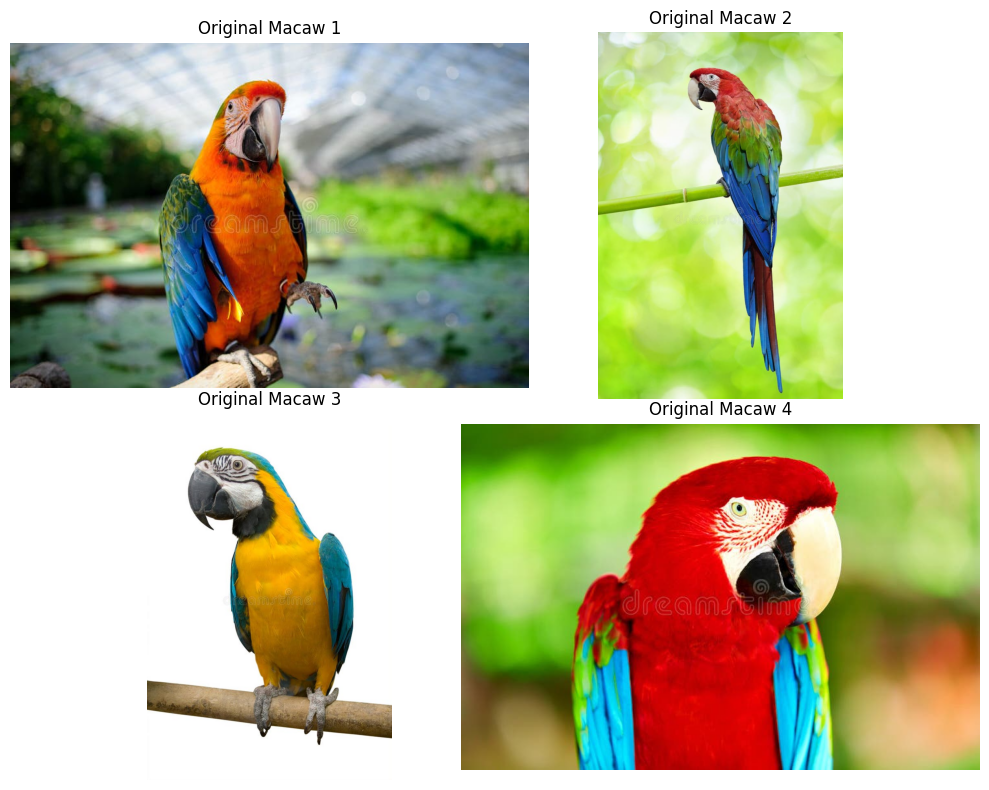

In [ ]:
plt.figure(figsize=(10, 8))

for i, img in enumerate(images):
    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(f"Original Macaw {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

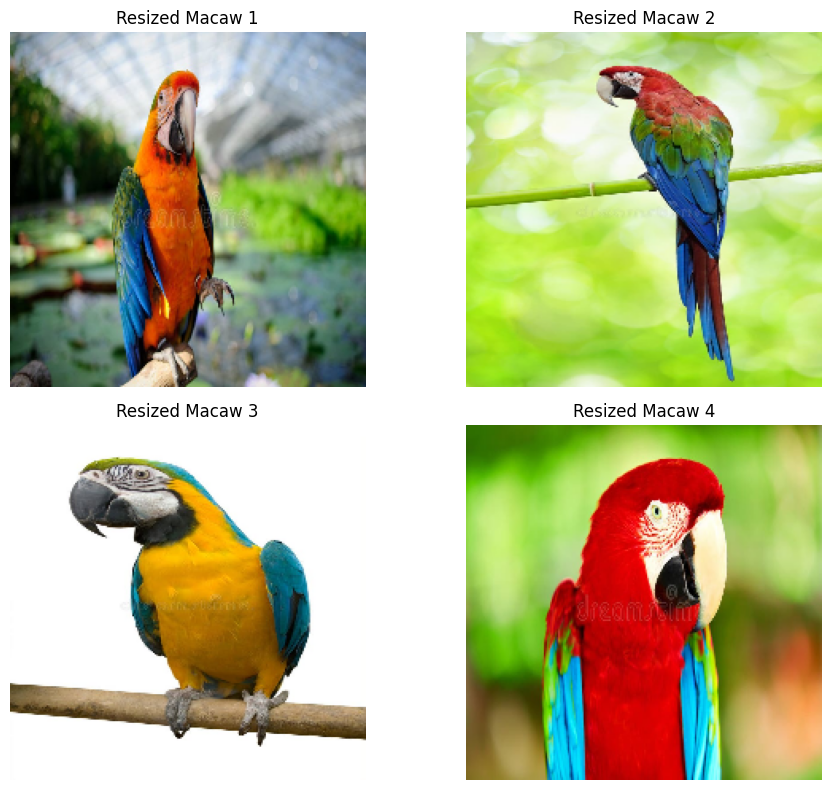

In [ ]:
resized_images = []

for img in images:
    resized = cv2.resize(img, (224, 224))
    resized_images.append(resized)

plt.figure(figsize=(10, 8))

for i, img in enumerate(resized_images):
    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(f"Resized Macaw {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

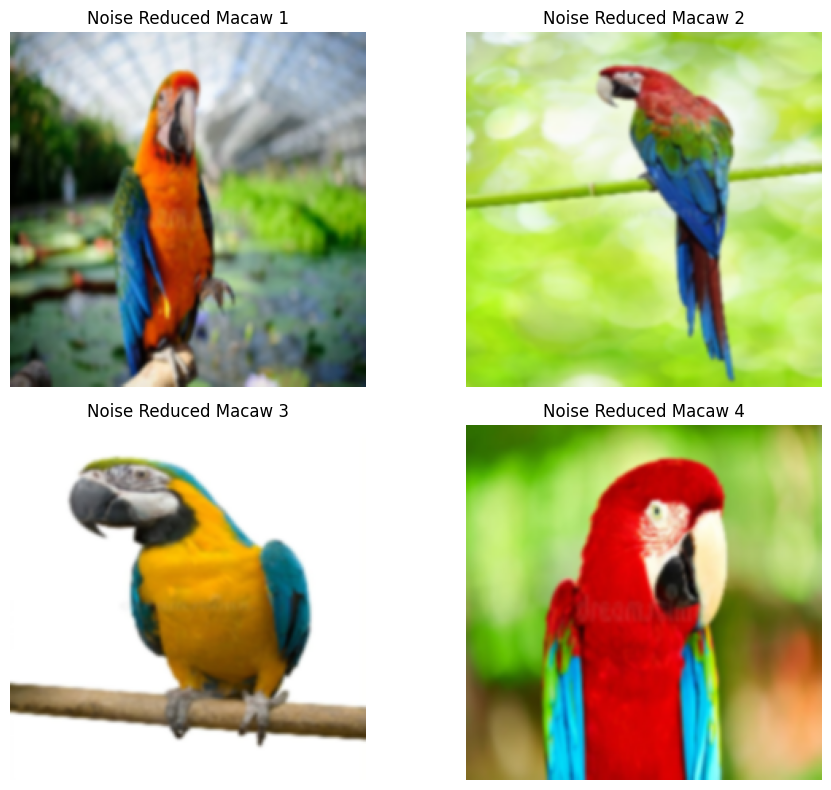

In [ ]:
denoised_images = []

for img in resized_images:
    denoised = cv2.GaussianBlur(img, (5, 5), 0)
    denoised_images.append(denoised)

plt.figure(figsize=(10, 8))

for i, img in enumerate(denoised_images):
    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(f"Noise Reduced Macaw {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

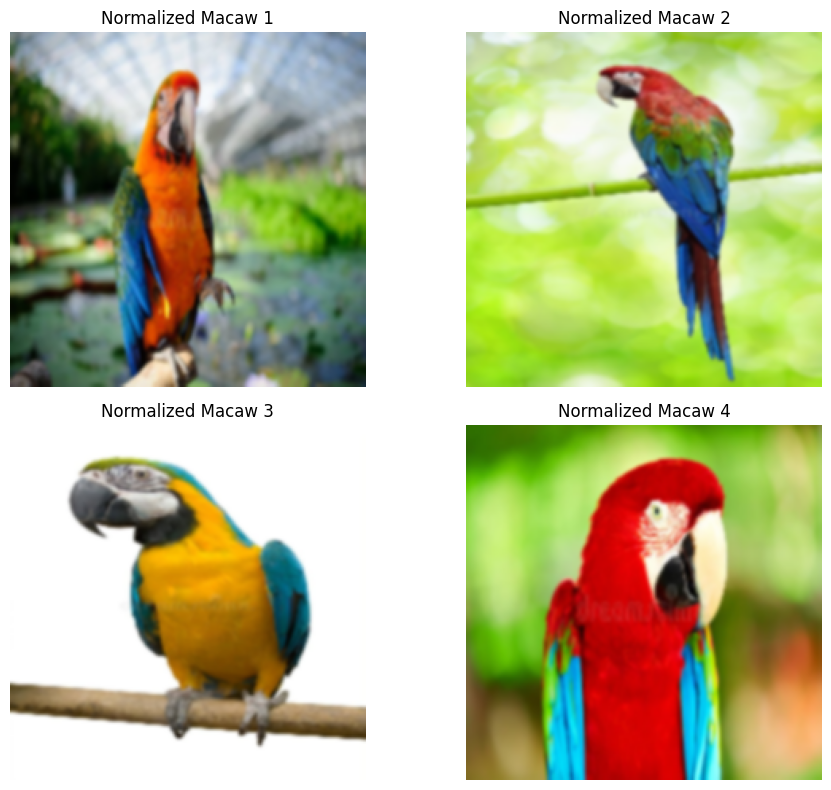

In [ ]:
normalized_images = []

for img in denoised_images:
    normalized = img.astype(np.float32) / 255.0
    normalized_images.append(normalized)

plt.figure(figsize=(10, 8))

for i, img in enumerate(normalized_images):
    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(f"Normalized Macaw {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 9: Preprocess All Macaw Images
# ============================================================

def preprocess_image(image_path):
    # Read the image
    img = cv2.imread(image_path)
    # Convert BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Resize
    resized = cv2.resize(img, (224, 224))
    # Denoise
    denoised = cv2.GaussianBlur(resized, (5, 5), 0)
    # Normalize
    normalized = denoised.astype(np.float32) / 255.0
    return normalized

processed_images = []

# Use uploaded.keys() to iterate over the specifically uploaded image files
for image_name in uploaded.keys():

    image_path = image_name # Since files.upload() puts them in the current directory, the filename is the path

    try:
        processed_image = preprocess_image(image_path)
        processed_images.append(processed_image)

    except Exception as e: # Catch specific exception for better debugging
        print(f"Skipped: {image_name} due to error: {e}")

processed_images = np.array(processed_images)

print("Preprocessed Macaw images shape:", processed_images.shape)

Preprocessed Macaw images shape: (15, 224, 224, 3)


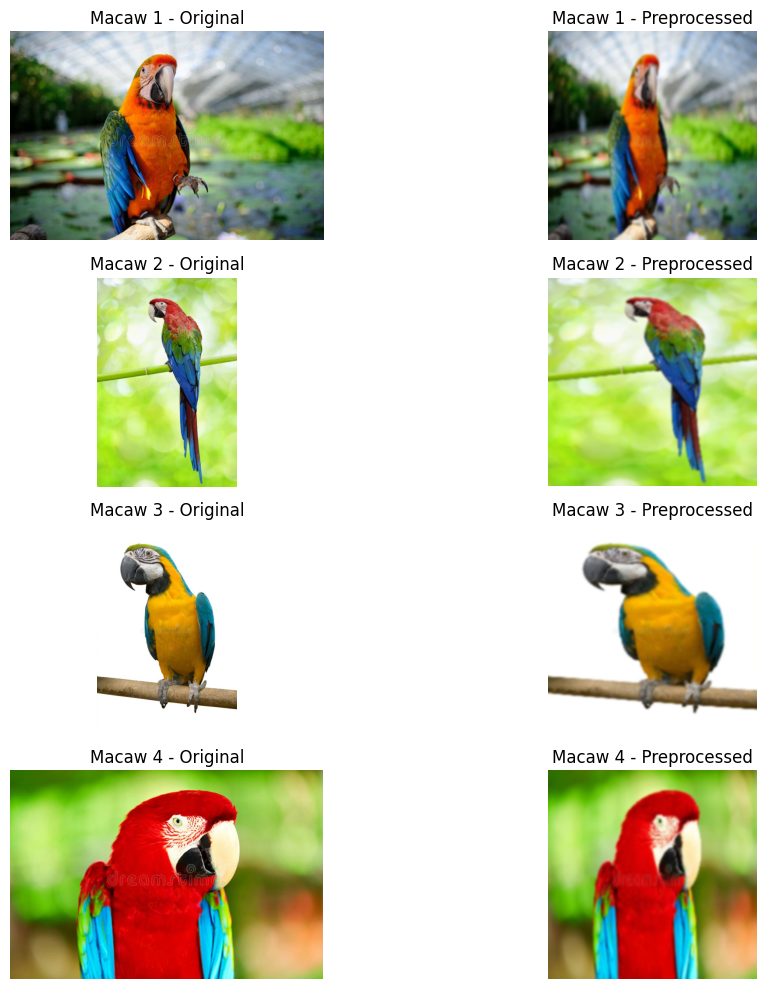

In [ ]:
plt.figure(figsize=(12, 10))

for i in range(4):

    # Original
    plt.subplot(4, 2, 2*i + 1)
    plt.imshow(images[i])
    plt.title(f"Macaw {i+1} - Original")
    plt.axis("off")

    # Preprocessed
    plt.subplot(4, 2, 2*i + 2)
    plt.imshow(normalized_images[i])
    plt.title(f"Macaw {i+1} - Preprocessed")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 10: Save Preprocessed Macaw Images
# ============================================================

output_path = "/content/macaw_preprocessed"

# Create output folder
os.makedirs(output_path, exist_ok=True)

for i, image in enumerate(processed_images):

    # Convert normalized image back to 0-255
    save_image = (image * 255).astype(np.uint8)

    # Save image
    image_name = f"macaw_{i+1}.jpg"
    image_path = os.path.join(output_path, image_name)

    cv2.imwrite(image_path, save_image)

print("All preprocessed Macaw images saved successfully!")
print("Location:", output_path)

All preprocessed Macaw images saved successfully!
Location: /content/macaw_preprocessed


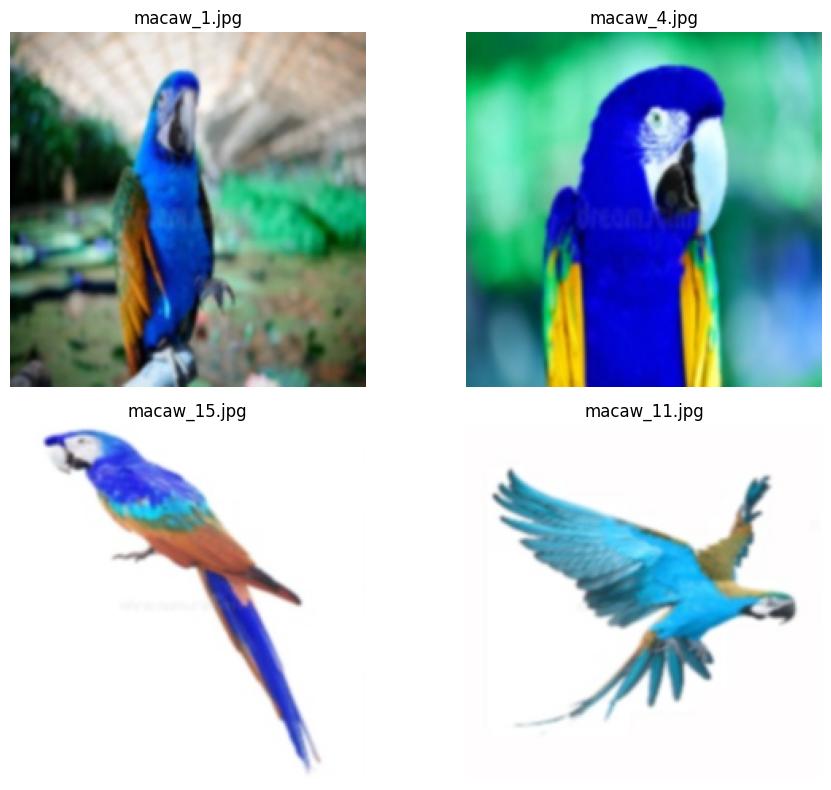

In [ ]:
# ============================================================
# CELL 11: Display Saved Preprocessed Images
# ============================================================

saved_files = os.listdir(output_path)

plt.figure(figsize=(10, 8))

for i, image_name in enumerate(saved_files[:4]):

    image_path = os.path.join(output_path, image_name)
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(image_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 11: Verify Saved Preprocessed Macaw Images
# ============================================================

print("Checking saved Macaw images...\n")

# Check whether folder exists
if os.path.exists(output_path):

    saved_files = os.listdir(output_path)

    print("Folder found:", output_path)
    print("Number of saved images:", len(saved_files))
    print("\nSaved files:")

    for file in saved_files:
        print(file)

else:
    print("Preprocessed image folder not found!")

Checking saved Macaw images...

Folder found: /content/macaw_preprocessed
Number of saved images: 15

Saved files:
macaw_1.jpg
macaw_4.jpg
macaw_15.jpg
macaw_11.jpg
macaw_13.jpg
macaw_9.jpg
macaw_10.jpg
macaw_14.jpg
macaw_2.jpg
macaw_6.jpg
macaw_3.jpg
macaw_5.jpg
macaw_12.jpg
macaw_8.jpg
macaw_7.jpg


In [ ]:
# ============================================================
# CELL 20: Compress the Preprocessed Macaw Dataset into ZIP
# ============================================================

import shutil

# This creates a ZIP file containing all preprocessed Macaw images
shutil.make_archive(
    "Preprocessed_Macaw",
    "zip",
    output_path
)

print("ZIP file created successfully!")
print("File name: Preprocessed_Macaw.zip")

ZIP file created successfully!
File name: Preprocessed_Macaw.zip


In [ ]:
# ============================================================
# CELL 21: Download the Final Preprocessed Macaw Dataset
# ============================================================

from google.colab import files

files.download("Preprocessed_Macaw.zip")

print("Download started!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started!


In [ ]:
# ============================================================
# CELL 22: Display Project Information
# ============================================================

print("=" * 50)
print("MACAW IMAGE PREPROCESSING PROJECT")
print("=" * 50)

print("Dataset Class    :", "Macaw")
print("Number of Images :", len(processed_images))
print("Resize Size      :", "224 × 224")
print("Noise Removal    :", "Gaussian Blur")
print("Normalization    :", "0–255 → 0–1")
print("Output Folder    :", output_path)

print("=" * 50)
print("PREPROCESSING COMPLETED SUCCESSFULLY")
print("=" * 50)

MACAW IMAGE PREPROCESSING PROJECT
Dataset Class    : Macaw
Number of Images : 15
Resize Size      : 224 × 224
Noise Removal    : Gaussian Blur
Normalization    : 0–255 → 0–1
Output Folder    : /content/macaw_preprocessed
PREPROCESSING COMPLETED SUCCESSFULLY
